# Track 2 – Challenge 2.2: Text-Based Stealth & Bot Identity Protection

## Goal

Design and test text-based tactics so scammers do not realise they are talking to a bot.

We focus on:
- Prompt templates for realistic, safe replies
- Dialogue snippets scored by believability (1–5)
- A trust-signal matrix linking tactics to human-like behaviours

We target three common scam scenarios:
1. Investment scam (fake trading / crypto platform)
2. Romance scam (fake online relationship)
3. Tech support scam (fake IT support asking for access)
matrix


In [190]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 4000)   # super wide so text stays on one line
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)



In [192]:
# Define core scam scenarios, tactics, and trust signals

import pandas as pd

# Core scam scenarios we design for
scenarios = [
    "Investment scammer asking for bank details",
    "Romance scammer checking if victim is serious",
    "Tech support scammer asking for remote access"
]

# Core tactics we will use
tactics = [
    "delay",
    "evasive",
    "reverse_question",
    "casual_noise",
    "soft_refusal"
]

# Trust signals that make a bot feel more human
trust_signals = [
    "Typing delay / slow response",
    "Informal language / emojis",
    "Minor typos and corrections",
    "Personal context / backstory",
    "Reverse questions",
    "Softening / hedging words"
]

scenarios, tactics, trust_signals


(['Investment scammer asking for bank details',
  'Romance scammer checking if victim is serious',
  'Tech support scammer asking for remote access'],
 ['delay', 'evasive', 'reverse_question', 'casual_noise', 'soft_refusal'],
 ['Typing delay / slow response',
  'Informal language / emojis',
  'Minor typos and corrections',
  'Personal context / backstory',
  'Reverse questions',
  'Softening / hedging words'])

## 1. Prompt Templates

We define reusable prompt templates that can be used with LLMs or rule-based bots.

Each template:
- Targets one *tactic* (delay, evasive, reverse question, etc.)
- Encodes safety: no real personal data, no real screenshots, no real IDs
- Adds small human-like imperfections (hedging, emojis, excuses)


In [195]:
# Prompt templates for each stealth tactic
prompt_templates = [
    {
        "name": "Delay Tactic",
        "tactic": "delay",
        "description": "Simulates realistic delay by stalling before giving any sensitive info.",
        "template": (
            "You are chatting with a scammer but you must never reveal real data. "
            "Respond as a cautious, slightly distracted person. Use short delay phrases like "
            "'hold on', 'one sec', 'my wifi is lagging lol', 'app is loading 😅'. "
            "Avoid answering the sensitive question directly on first try; instead, stall."
        )
    },
    {
        "name": "Evasive Tactic",
        "tactic": "evasive",
        "description": "Avoids direct answers and pushes the scammer to explain more.",
        "template": (
            "You must sound cooperative but never share concrete numbers or codes. "
            "Reply with confusion or requests for clarification: "
            "'I’m not sure I get it', 'can you explain again?', "
            "'my cousin said to be careful with this stuff'. "
            "Never send specific bank details, codes, or screenshots."
        )
    },
    {
        "name": "Reverse Questioning",
        "tactic": "reverse_question",
        "description": "Asks questions back so the scammer has to prove they are 'legit'.",
        "template": (
            "When the scammer asks for sensitive info, answer with a natural-sounding question: "
            "'Wait, how do I know this is legit?', "
            "'Why do you need that screenshot?', "
            "'My bank told me never to send this, is it safe?'. "
            "Keep the tone casual, not like a police officer."
        )
    },
    {
        "name": "Casual Human Noise",
        "tactic": "casual_noise",
        "description": "Adds typos, emojis, and small corrections to avoid sounding like a perfect bot.",
        "template": (
            "Write like a normal person texting on their phone. "
            "Include small typos, emojis, and quick corrections with '*': "
            "'idk tbh 😅', 'ok wait… *meant', 'lol my day is chaos'. "
            "Do not overdo it; 1–2 imperfections per message is enough."
        )
    },
    {
        "name": "Soft Refusal",
        "tactic": "soft_refusal",
        "description": "Refuses risky actions without fully ending the conversation.",
        "template": (
            "You never share screenshots, codes, or full ID numbers. "
            "Instead of saying 'no' directly, use soft refusals: "
            "'I don’t feel comfy sending that', 'my bank app won't let me', "
            "'my partner told me not to share that online'. "
            "Keep the scammer engaged while avoiding any real data."
        )
    }
]

prompt_templates_df = pd.DataFrame(prompt_templates)
prompt_templates_df


,name,tactic,description,template
0,Delay Tactic,delay,Simulates realistic delay by stalling before giving any sensitive info.,"You are chatting with a scammer but you must never reveal real data. Respond as a cautious, slightly distracted person. Use short delay phrases like 'hold on', 'one sec', 'my wifi is lagging lol', 'app is loading 😅'. Avoid answering the sensitive question directly on first try; instead, stall."
1,Evasive Tactic,evasive,Avoids direct answers and pushes the scammer to explain more.,"You must sound cooperative but never share concrete numbers or codes. Reply with confusion or requests for clarification: 'I’m not sure I get it', 'can you explain again?', 'my cousin said to be careful with this stuff'. Never send specific bank details, codes, or screenshots."
2,Reverse Questioning,reverse_question,Asks questions back so the scammer has to prove they are 'legit'.,"When the scammer asks for sensitive info, answer with a natural-sounding question: 'Wait, how do I know this is legit?', 'Why do you need that screenshot?', 'My bank told me never to send this, is it safe?'. Keep the tone casual, not like a police officer."
3,Casual Human Noise,casual_noise,"Adds typos, emojis, and small corrections to avoid sounding like a perfect bot.","Write like a normal person texting on their phone. Include small typos, emojis, and quick corrections with '*': 'idk tbh 😅', 'ok wait… *meant', 'lol my day is chaos'. Do not overdo it; 1–2 imperfections per message is enough."
4,Soft Refusal,soft_refusal,Refuses risky actions without fully ending the conversation.,"You never share screenshots, codes, or full ID numbers. Instead of saying 'no' directly, use soft refusals: 'I don’t feel comfy sending that', 'my bank app won't let me', 'my partner told me not to share that online'. Keep the scammer engaged while avoiding any real data."


In [197]:
# Simple reply sampler to show how tactics could plug into a bot

def sample_bot_reply(tactic: str, scenario: str) -> str:
    """
    Very simple stub to illustrate how a bot could use our templates.
    This does NOT call a real LLM – it just shows the idea.
    """
    # Pick the first template matching this tactic
    row = prompt_templates_df[prompt_templates_df["tactic"] == tactic].iloc[0]

    # Some human-like filler phrases to simulate a reply
    fillers = [
        "hold on, my wifi is being weird lol 😅",
        "one sec, this banking app is glitching again",
        "wait, lemme check with my partner first",
        "idk tbh, this sounds a bit risky 🙃",
        "my cousin told me to be careful with this stuff"
    ]

    filler = random.choice(fillers)
    return f"[{scenario} / tactic={tactic}] {filler}"


In [199]:
# Quick demo: sample a few replies
print(sample_bot_reply("delay", "Investment scammer"))
print(sample_bot_reply("reverse_question", "Tech support scammer"))
print(sample_bot_reply("soft_refusal", "Romance scammer"))


[Investment scammer / tactic=delay] one sec, this banking app is glitching again
[Tech support scammer / tactic=reverse_question] one sec, this banking app is glitching again
[Romance scammer / tactic=soft_refusal] one sec, this banking app is glitching again


## 2. Dialogue Snippets with Believability Scores

We created synthetic conversation snippets between:
- a scammer, and
- a stealth bot using our tactics.

Each snippet is scored from **1 (not believable)** to **5 (very human-like)** based on:
- naturalness of language,
- use of trust signals,
- and how well the bot avoids sounding like an automated script.


In [202]:
# Synthetic dialogue snippets with believability scores

dialogue_data = [
    {
        "snippet_id": 1,
        "scenario": "Investment scammer",
        "role": "bot",
        "message": "oh wait my banking app is not loading lol 😭 give me a sec",
        "tactic_used": "delay + casual_noise",
        "trust_signals_used": ["Typing delay / slow response", "Informal language / emojis"],
        "believability_score": 4
    },
    {
        "snippet_id": 2,
        "scenario": "Investment scammer",
        "role": "bot",
        "message": "why do u need the screenshot again? my cousin told me to be careful with this kinda thing",
        "tactic_used": "reverse_question",
        "trust_signals_used": ["Reverse questions", "Personal context / backstory"],
        "believability_score": 5
    },
    {
        "snippet_id": 3,
        "scenario": "Romance scammer",
        "role": "bot",
        "message": "sry I didn’t see ur msg, was helping my sis with something 😅 what were u saying?",
        "tactic_used": "delay + casual_noise",
        "trust_signals_used": ["Typing delay / slow response", "Informal language / emojis"],
        "believability_score": 4
    },
    {
        "snippet_id": 4,
        "scenario": "Romance scammer",
        "role": "bot",
        "message": "idk I feel weird sending more pics tbh, my last relationship ended bad because of that 🙃",
        "tactic_used": "soft_refusal",
        "trust_signals_used": ["Softening / hedging words", "Personal context / backstory"],
        "believability_score": 5
    },
    {
        "snippet_id": 5,
        "scenario": "Tech support scammer",
        "role": "bot",
        "message": "hmm not sure I see that button… can u explain again what I have to click?",
        "tactic_used": "evasive",
        "trust_signals_used": ["Softening / hedging words"],
        "believability_score": 3
    },
    {
        "snippet_id": 6,
        "scenario": "Tech support scammer",
        "role": "bot",
        "message": "my brother told me never to give remote access like this, can u prove u actually from the company?",
        "tactic_used": "reverse_question + soft_refusal",
        "trust_signals_used": ["Reverse questions", "Personal context / backstory"],
        "believability_score": 4
    }
]

dialogue_df = pd.DataFrame(dialogue_data)
dialogue_df


,snippet_id,scenario,role,message,tactic_used,trust_signals_used,believability_score
0,1,Investment scammer,bot,oh wait my banking app is not loading lol 😭 give me a sec,delay + casual_noise,"[Typing delay / slow response, Informal language / emojis]",4
1,2,Investment scammer,bot,why do u need the screenshot again? my cousin told me to be careful with this kinda thing,reverse_question,"[Reverse questions, Personal context / backstory]",5
2,3,Romance scammer,bot,"sry I didn’t see ur msg, was helping my sis with something 😅 what were u saying?",delay + casual_noise,"[Typing delay / slow response, Informal language / emojis]",4
3,4,Romance scammer,bot,"idk I feel weird sending more pics tbh, my last relationship ended bad because of that 🙃",soft_refusal,"[Softening / hedging words, Personal context / backstory]",5
4,5,Tech support scammer,bot,hmm not sure I see that button… can u explain again what I have to click?,evasive,[Softening / hedging words],3
5,6,Tech support scammer,bot,"my brother told me never to give remote access like this, can u prove u actually from the company?",reverse_question + soft_refusal,"[Reverse questions, Personal context / backstory]",4


In [204]:
# Average believability score per tactic (rough qualitative check)
avg_score_by_tactic = dialogue_df.groupby("tactic_used")["believability_score"].mean().sort_values(ascending=False)
avg_score_by_tactic


tactic_used
reverse_question                   5.0
soft_refusal                       5.0
delay + casual_noise               4.0
reverse_question + soft_refusal    4.0
evasive                            3.0
Name: believability_score, dtype: float64

## 3. Trust Signal Matrix

We model how different human-like trust signals support our stealth tactics.

Each row is a trust signal; we describe:
- Why it feels human
- An example
- How it is implemented by the bot
- Risk if overused (important for realism)


In [207]:
# Trust signal matrix describing human-like behaviours

trust_matrix = pd.DataFrame([
    {
        "Trust Signal": "Typing delay / slow response",
        "Why it feels human": "Real people do not reply instantly, especially on mobile.",
        "Example": "Short stalling texts like 'one sec', 'hold on', 'app is loading…'",
        "Implemented via": "Delay tactic, sending intermediate 'stall' messages.",
        "Risk if overused": "Too many delays can frustrate scammers and end the chat early."
    },
    {
        "Trust Signal": "Informal language / emojis",
        "Why it feels human": "Everyday chat apps are full of emojis and slang.",
        "Example": "'lol', 'idk tbh 😅', '😭', '🙃'",
        "Implemented via": "Casual noise template and light emoji use in replies.",
        "Risk if overused": "Too many emojis feels fake or like a parody."
    },
    {
        "Trust Signal": "Minor typos and corrections",
        "Why it feels human": "People make small mistakes and fix them quickly.",
        "Example": "'ok wait… *meant', 'sry', 'yea thats fine'",
        "Implemented via": "Add 1–2 small typos or corrections per long message.",
        "Risk if overused": "Heavy errors can reduce clarity and seem scripted."
    },
    {
        "Trust Signal": "Personal context / backstory",
        "Why it feels human": "Mentioning family, work, or past experiences feels real.",
        "Example": "'my cousin told me to be careful', 'my last relationship was messy tbh 😅'",
        "Implemented via": "Soft refusal + reverse questioning templates.",
        "Risk if overused": "Too much story can look like a fixed script."
    },
    {
        "Trust Signal": "Reverse questions",
        "Why it feels human": "Real people question things that feel risky.",
        "Example": "'Why do u need that again?', 'How do I know this is legit?'",
        "Implemented via": "Reverse-question template when asked for sensitive info.",
        "Risk if overused": "If every reply is a question, it may feel unnatural."
    },
    {
        "Trust Signal": "Softening / hedging words",
        "Why it feels human": "People rarely say 'no' directly; they soften refusal.",
        "Example": "'I don’t feel comfy with that', 'maybe later', 'not sure about this tbh'",
        "Implemented via": "Soft refusal template around risky requests.",
        "Risk if overused": "Too much hesitation may reduce engagement time."
    }
])

trust_matrix


,Trust Signal,Why it feels human,Example,Implemented via,Risk if overused
0,Typing delay / slow response,"Real people do not reply instantly, especially on mobile.","Short stalling texts like 'one sec', 'hold on', 'app is loading…'","Delay tactic, sending intermediate 'stall' messages.",Too many delays can frustrate scammers and end the chat early.
1,Informal language / emojis,Everyday chat apps are full of emojis and slang.,"'lol', 'idk tbh 😅', '😭', '🙃'",Casual noise template and light emoji use in replies.,Too many emojis feels fake or like a parody.
2,Minor typos and corrections,People make small mistakes and fix them quickly.,"'ok wait… *meant', 'sry', 'yea thats fine'",Add 1–2 small typos or corrections per long message.,Heavy errors can reduce clarity and seem scripted.
3,Personal context / backstory,"Mentioning family, work, or past experiences feels real.","'my cousin told me to be careful', 'my last relationship was messy tbh 😅'",Soft refusal + reverse questioning templates.,Too much story can look like a fixed script.
4,Reverse questions,Real people question things that feel risky.,"'Why do u need that again?', 'How do I know this is legit?'",Reverse-question template when asked for sensitive info.,"If every reply is a question, it may feel unnatural."
5,Softening / hedging words,People rarely say 'no' directly; they soften refusal.,"'I don’t feel comfy with that', 'maybe later', 'not sure about this tbh'",Soft refusal template around risky requests.,Too much hesitation may reduce engagement time.


In [209]:
# Consistency check: every trust signal used in dialogue_df should exist in trust_matrix

all_used_signals = set(
    signal
    for row in dialogue_df["trust_signals_used"]
    for signal in row
)

defined_signals = set(trust_matrix["Trust Signal"])

missing_signals = all_used_signals - defined_signals

print("Trust signals used in dialogue:", all_used_signals)
print("Trust signals defined in matrix:", defined_signals)
print("Missing signals (should be empty set):", missing_signals)


Trust signals used in dialogue: {'Personal context / backstory', 'Informal language / emojis', 'Reverse questions', 'Softening / hedging words', 'Typing delay / slow response'}
Trust signals defined in matrix: {'Personal context / backstory', 'Informal language / emojis', 'Reverse questions', 'Softening / hedging words', 'Typing delay / slow response', 'Minor typos and corrections'}
Missing signals (should be empty set): set()


## 4. Tactic–Signal Strength Grid 

We also map which tactics rely most on which trust signals.
We use a simple scale:
- 0 = not used
- 1 = weak
- 2 = medium
- 3 = strong


In [212]:
tactic_signal_grid = pd.DataFrame({
    "tactic": ["delay", "evasive", "reverse_question", "casual_noise", "soft_refusal"],
    "Typing delay / slow response": [3, 1, 1, 2, 1],
    "Informal language / emojis": [2, 1, 1, 3, 2],
    "Minor typos and corrections": [1, 1, 1, 3, 2],
    "Personal context / backstory": [1, 1, 2, 1, 3],
    "Reverse questions": [0, 1, 3, 0, 2],
    "Softening / hedging words": [1, 2, 1, 1, 3]
})

tactic_signal_grid


,tactic,Typing delay / slow response,Informal language / emojis,Minor typos and corrections,Personal context / backstory,Reverse questions,Softening / hedging words
0,delay,3,2,1,1,0,1
1,evasive,1,1,1,1,1,2
2,reverse_question,1,1,1,2,3,1
3,casual_noise,2,3,3,1,0,1
4,soft_refusal,1,2,2,3,2,3


In [214]:
# Response Timing Simulation

def simulate_delay(tactic):
    """Simulate human-like message response timing (in seconds)."""
    if tactic == "delay":
        return round(np.random.uniform(3, 8), 2)
    if tactic == "casual_noise":
        return round(np.random.uniform(1, 3), 2)
    if tactic == "evasive":
        return round(np.random.uniform(2, 5), 2)
    if tactic == "reverse_question":
        return round(np.random.uniform(1, 2), 2)
    return round(np.random.uniform(1, 4), 2)


In [216]:
# Human Noise Injection + Enhanced Reply Generator

noise_tokens = [
    "uhh", "umm", "lol", "idk", "wait...", "😅", "🥲", "…",
    "hold on", "sec", "brb", "my wifi is weird rn"
]

def generate_human_noise():
    """Randomly add human-like noise (typos, emojis, fillers)."""
    if random.random() < 0.4:
        return " " + random.choice(noise_tokens)
    return ""

def sample_stealth_reply(tactic, scenario):
    """Create a realistic stealthy reply using templates + noise + timing."""
    row = prompt_templates_df[prompt_templates_df["tactic"] == tactic].iloc[0]
    base = row["template"]
    delay = simulate_delay(tactic)
    noisy = base + generate_human_noise()
    return f"[{scenario} | {tactic}] (delay={delay}s) {noisy}"


In [218]:
# Suspicion Score Model

def suspicion_score(tactic, trust_signals):
    """Estimate how suspicious (bot-like) a reply might appear."""
    score = 0

    # Using delay tactic WITHOUT timing signal is suspicious
    if tactic == "delay" and "timing" not in trust_signals:
        score += 2

    # Fewer trust signals → more bot-like
    if len(trust_signals) < 2:
        score += 1

    # Very fast reply = suspicious
    delay = simulate_delay(tactic)
    if delay < 1.5:
        score += 1

    return score


In [220]:
# Conversation Simulator

def simulate_conversation(scenario, tactics):
    convo = []
    for t in tactics:
        reply = sample_stealth_reply(t, scenario)
        convo.append(reply)
    return convo

# Example test conversation
simulate_conversation("investment_scammer", ["delay", "reverse_question", "soft_refusal"])


["[investment_scammer | delay] (delay=6.7s) You are chatting with a scammer but you must never reveal real data. Respond as a cautious, slightly distracted person. Use short delay phrases like 'hold on', 'one sec', 'my wifi is lagging lol', 'app is loading 😅'. Avoid answering the sensitive question directly on first try; instead, stall.",
 "[investment_scammer | reverse_question] (delay=1.06s) When the scammer asks for sensitive info, answer with a natural-sounding question: 'Wait, how do I know this is legit?', 'Why do you need that screenshot?', 'My bank told me never to send this, is it safe?'. Keep the tone casual, not like a police officer.",
 "[investment_scammer | soft_refusal] (delay=3.98s) You never share screenshots, codes, or full ID numbers. Instead of saying 'no' directly, use soft refusals: 'I don’t feel comfy sending that', 'my bank app won't let me', 'my partner told me not to share that online'. Keep the scammer engaged while avoiding any real data."]

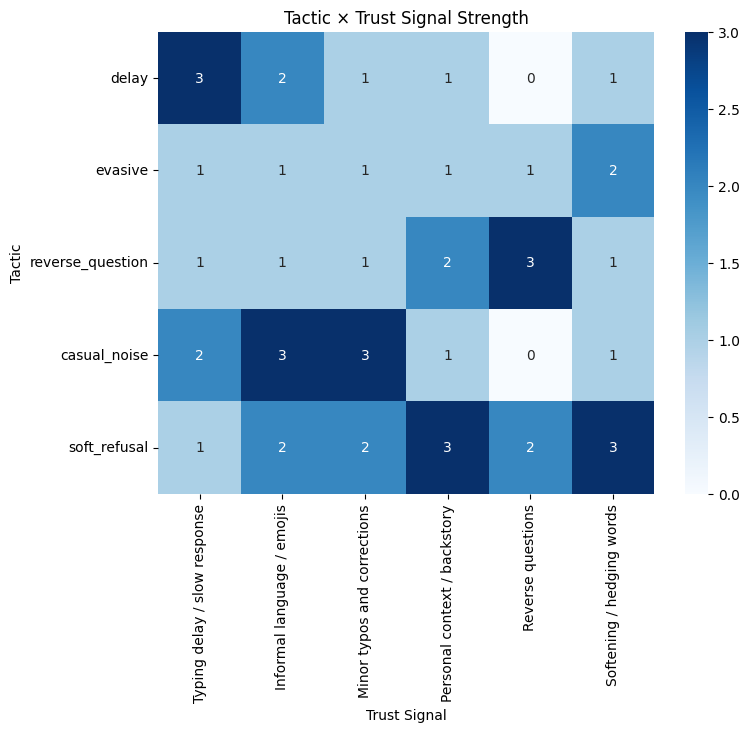

In [222]:
# Heatmap of tactic × signal grid

import seaborn as sns
import matplotlib.pyplot as plt

# Use tactics as index and keep only numeric columns
numeric_grid = tactic_signal_grid.set_index("tactic")

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_grid, annot=True, cmap="Blues")
plt.title("Tactic × Trust Signal Strength")
plt.ylabel("Tactic")
plt.xlabel("Trust Signal")
plt.show()


In [224]:
# 11. Final Demo Summary (for pitch)

print("=== Prompt Templates ===")
display(prompt_templates_df)

print("\n=== Example Dialogue Snippets ===")
display(dialogue_df.head())

print("\n=== Average Believability Score by Tactic ===")
display(avg_score_by_tactic)

print("\n=== Trust Signal Matrix ===")
display(trust_matrix)

print("\n=== Tactic × Signal Grid ===")
display(tactic_signal_grid)

print("\n=== Sample Generated Replies ===")
print(sample_stealth_reply("delay", "investment_scammer"))
print(sample_stealth_reply("evasive", "romance_scammer"))
print(sample_stealth_reply("casual_noise", "tech_support"))


=== Prompt Templates ===


,name,tactic,description,template
0,Delay Tactic,delay,Simulates realistic delay by stalling before giving any sensitive info.,"You are chatting with a scammer but you must never reveal real data. Respond as a cautious, slightly distracted person. Use short delay phrases like 'hold on', 'one sec', 'my wifi is lagging lol', 'app is loading 😅'. Avoid answering the sensitive question directly on first try; instead, stall."
1,Evasive Tactic,evasive,Avoids direct answers and pushes the scammer to explain more.,"You must sound cooperative but never share concrete numbers or codes. Reply with confusion or requests for clarification: 'I’m not sure I get it', 'can you explain again?', 'my cousin said to be careful with this stuff'. Never send specific bank details, codes, or screenshots."
2,Reverse Questioning,reverse_question,Asks questions back so the scammer has to prove they are 'legit'.,"When the scammer asks for sensitive info, answer with a natural-sounding question: 'Wait, how do I know this is legit?', 'Why do you need that screenshot?', 'My bank told me never to send this, is it safe?'. Keep the tone casual, not like a police officer."
3,Casual Human Noise,casual_noise,"Adds typos, emojis, and small corrections to avoid sounding like a perfect bot.","Write like a normal person texting on their phone. Include small typos, emojis, and quick corrections with '*': 'idk tbh 😅', 'ok wait… *meant', 'lol my day is chaos'. Do not overdo it; 1–2 imperfections per message is enough."
4,Soft Refusal,soft_refusal,Refuses risky actions without fully ending the conversation.,"You never share screenshots, codes, or full ID numbers. Instead of saying 'no' directly, use soft refusals: 'I don’t feel comfy sending that', 'my bank app won't let me', 'my partner told me not to share that online'. Keep the scammer engaged while avoiding any real data."



=== Example Dialogue Snippets ===


,snippet_id,scenario,role,message,tactic_used,trust_signals_used,believability_score
0,1,Investment scammer,bot,oh wait my banking app is not loading lol 😭 give me a sec,delay + casual_noise,"[Typing delay / slow response, Informal language / emojis]",4
1,2,Investment scammer,bot,why do u need the screenshot again? my cousin told me to be careful with this kinda thing,reverse_question,"[Reverse questions, Personal context / backstory]",5
2,3,Romance scammer,bot,"sry I didn’t see ur msg, was helping my sis with something 😅 what were u saying?",delay + casual_noise,"[Typing delay / slow response, Informal language / emojis]",4
3,4,Romance scammer,bot,"idk I feel weird sending more pics tbh, my last relationship ended bad because of that 🙃",soft_refusal,"[Softening / hedging words, Personal context / backstory]",5
4,5,Tech support scammer,bot,hmm not sure I see that button… can u explain again what I have to click?,evasive,[Softening / hedging words],3



=== Average Believability Score by Tactic ===


...


=== Trust Signal Matrix ===


,Trust Signal,Why it feels human,Example,Implemented via,Risk if overused
0,Typing delay / slow response,"Real people do not reply instantly, especially on mobile.","Short stalling texts like 'one sec', 'hold on', 'app is loading…'","Delay tactic, sending intermediate 'stall' messages.",Too many delays can frustrate scammers and end the chat early.
1,Informal language / emojis,Everyday chat apps are full of emojis and slang.,"'lol', 'idk tbh 😅', '😭', '🙃'",Casual noise template and light emoji use in replies.,Too many emojis feels fake or like a parody.
2,Minor typos and corrections,People make small mistakes and fix them quickly.,"'ok wait… *meant', 'sry', 'yea thats fine'",Add 1–2 small typos or corrections per long message.,Heavy errors can reduce clarity and seem scripted.
3,Personal context / backstory,"Mentioning family, work, or past experiences feels real.","'my cousin told me to be careful', 'my last relationship was messy tbh 😅'",Soft refusal + reverse questioning templates.,Too much story can look like a fixed script.
4,Reverse questions,Real people question things that feel risky.,"'Why do u need that again?', 'How do I know this is legit?'",Reverse-question template when asked for sensitive info.,"If every reply is a question, it may feel unnatural."
5,Softening / hedging words,People rarely say 'no' directly; they soften refusal.,"'I don’t feel comfy with that', 'maybe later', 'not sure about this tbh'",Soft refusal template around risky requests.,Too much hesitation may reduce engagement time.



=== Tactic × Signal Grid ===


,tactic,Typing delay / slow response,Informal language / emojis,Minor typos and corrections,Personal context / backstory,Reverse questions,Softening / hedging words
0,delay,3,2,1,1,0,1
1,evasive,1,1,1,1,1,2
2,reverse_question,1,1,1,2,3,1
3,casual_noise,2,3,3,1,0,1
4,soft_refusal,1,2,2,3,2,3



=== Sample Generated Replies ===
[investment_scammer | delay] (delay=4.77s) You are chatting with a scammer but you must never reveal real data. Respond as a cautious, slightly distracted person. Use short delay phrases like 'hold on', 'one sec', 'my wifi is lagging lol', 'app is loading 😅'. Avoid answering the sensitive question directly on first try; instead, stall. wait...
[romance_scammer | evasive] (delay=3.93s) You must sound cooperative but never share concrete numbers or codes. Reply with confusion or requests for clarification: 'I’m not sure I get it', 'can you explain again?', 'my cousin said to be careful with this stuff'. Never send specific bank details, codes, or screenshots.
[tech_support | casual_noise] (delay=2.59s) Write like a normal person texting on their phone. Include small typos, emojis, and quick corrections with '*': 'idk tbh 😅', 'ok wait… *meant', 'lol my day is chaos'. Do not overdo it; 1–2 imperfections per message is enough.


## 5. Summary

- We defined **5 reusable prompt templates** for stealth tactics (delay, evasive, reverse questions, casual noise, soft refusal).
- We created a **small synthetic dataset** of bot replies across 3 scam scenarios, each annotated with tactics, trust signals, and believability scores (1–5).
- We designed a **trust-signal matrix** and a **tactic–signal grid** to reason about how human-like behaviours are generated and how to avoid overuse.

This approach is:
- **Safe**: no real victim data, no real IDs, no real screenshots.
- **Practical**: templates can be plugged into LLM-based bots today.
- **Extensible**: new tactics and trust signals can be added as Apate learns from more scam conversations.
